In [2]:
import pandas as pd

df1 = pd.read_csv("data/T_ONTIME_REPORTING.csv")
df2 = pd.read_csv("data/T_ONTIME_REPORTING 2.csv")

print("DF1 shape:", df1.shape)
print("DF2 shape:", df2.shape)

print("\nDF1 columns:")
print(df1.columns.tolist())

print("\nDF2 columns:")
print(df2.columns.tolist())

DF1 shape: (539747, 19)
DF2 shape: (583985, 21)

DF1 columns:
['YEAR', 'MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK', 'OP_UNIQUE_CARRIER', 'ORIGIN_CITY_NAME', 'DEST_CITY_NAME', 'CRS_DEP_TIME', 'DEP_DELAY', 'DEP_DEL15', 'CRS_ARR_TIME', 'CANCELLED', 'DIVERTED', 'DISTANCE', 'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY']

DF2 columns:
['YEAR', 'MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK', 'OP_UNIQUE_CARRIER', 'ORIGIN', 'ORIGIN_CITY_NAME', 'DEST', 'DEST_CITY_NAME', 'CRS_DEP_TIME', 'DEP_DELAY', 'DEP_DEL15', 'CRS_ARR_TIME', 'CANCELLED', 'DIVERTED', 'DISTANCE', 'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY']


In [3]:
import pandas as pd

df = pd.read_csv("data/T_ONTIME_REPORTING 2.csv")

# Remove cancelled and diverted flights
df = df[(df["CANCELLED"] == 0) & (df["DIVERTED"] == 0)]

# Drop leakage columns
df = df.drop(columns=[
    "DEP_DELAY",
    "CARRIER_DELAY",
    "WEATHER_DELAY",
    "NAS_DELAY",
    "SECURITY_DELAY",
    "LATE_AIRCRAFT_DELAY"
])

# Drop any remaining missing values
df = df.dropna()

print(df.shape)
df.head()

(565963, 15)


,YEAR,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,ORIGIN,ORIGIN_CITY_NAME,DEST,DEST_CITY_NAME,CRS_DEP_TIME,DEP_DEL15,CRS_ARR_TIME,CANCELLED,DIVERTED,DISTANCE
0,2019,1,1,2,9E,ABE,"Allentown/Bethlehem/Easton, PA",ATL,"Atlanta, GA",600,0.0,828,0.0,0.0,692.0
1,2019,1,1,2,9E,AEX,"Alexandria, LA",ATL,"Atlanta, GA",1022,0.0,1305,0.0,0.0,500.0
2,2019,1,1,2,9E,AEX,"Alexandria, LA",ATL,"Atlanta, GA",1740,0.0,2027,0.0,0.0,500.0
3,2019,1,1,2,9E,AGS,"Augusta, GA",ATL,"Atlanta, GA",610,0.0,715,0.0,0.0,143.0
4,2019,1,1,2,9E,AGS,"Augusta, GA",ATL,"Atlanta, GA",805,0.0,916,0.0,0.0,143.0


In [4]:
# Create departure hour
df["DepHour"] = df["CRS_DEP_TIME"] // 100

# Create weekend feature
df["IsWeekend"] = df["DAY_OF_WEEK"].isin([6, 7]).astype(int)

# Create peak hour feature
df["IsPeakHour"] = df["DepHour"].isin([6,7,8,16,17,18,19]).astype(int)

df.head()

,YEAR,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,ORIGIN,ORIGIN_CITY_NAME,DEST,DEST_CITY_NAME,CRS_DEP_TIME,DEP_DEL15,CRS_ARR_TIME,CANCELLED,DIVERTED,DISTANCE,DepHour,IsWeekend,IsPeakHour
0,2019,1,1,2,9E,ABE,"Allentown/Bethlehem/Easton, PA",ATL,"Atlanta, GA",600,0.0,828,0.0,0.0,692.0,6,0,1
1,2019,1,1,2,9E,AEX,"Alexandria, LA",ATL,"Atlanta, GA",1022,0.0,1305,0.0,0.0,500.0,10,0,0
2,2019,1,1,2,9E,AEX,"Alexandria, LA",ATL,"Atlanta, GA",1740,0.0,2027,0.0,0.0,500.0,17,0,1
3,2019,1,1,2,9E,AGS,"Augusta, GA",ATL,"Atlanta, GA",610,0.0,715,0.0,0.0,143.0,6,0,1
4,2019,1,1,2,9E,AGS,"Augusta, GA",ATL,"Atlanta, GA",805,0.0,916,0.0,0.0,143.0,8,0,1


In [7]:
top_airports = df["ORIGIN"].value_counts().head(20)
top_airports

ORIGIN
ATL    30783
ORD    23336
DFW    22705
CLT    18772
DEN    18220
LAX    17660
PHX    14540
IAH    14463
LGA    13350
SFO    13078
LAS    13045
MSP    11920
MCO    11837
DTW    11751
DCA    11178
BOS    10704
EWR    10244
JFK    10239
SEA    10120
SLC     9238
Name: count, dtype: int64

In [10]:
weather_raw = pd.read_csv(
    "data/changeme.txt",
    sep="\t",
    na_values=["M", "NA", ""]
)

print(weather_raw.shape)
weather_raw.head()

(1613634, 20)


/var/folders/gv/szrr6w4d013f4hb10fpwn_8h0000gn/T/ipykernel_23876/4016883082.py:1: DtypeWarning: Columns (12,14) have mixed types. Specify dtype option on import or set low_memory=False.
  weather_raw = pd.read_csv(


,station,station_name,valid(UTC),tmpf,dwpf,sknt,drct,gust_drct,gust_sknt,vis1_coeff,vis1_nd,vis2_coeff,vis2_nd,vis3_coeff,vis3_nd,ptype,precip,pres1,pres2,pres3
0,ATL,ATLANTA INTL ARPT,2019-01-01 00:00,68.0,60.0,11.0,176.0,182.0,15.0,0.091,N,0.068,N,NaN,NaN,NP,0.0,29.002,29.006,29.009
1,ATL,ATLANTA INTL ARPT,2019-01-01 00:01,68.0,60.0,11.0,171.0,183.0,13.0,0.093,N,0.068,N,NaN,NaN,NP,0.0,29.000,29.004,29.008
2,ATL,ATLANTA INTL ARPT,2019-01-01 00:02,68.0,60.0,10.0,169.0,186.0,14.0,0.091,N,0.069,N,NaN,NaN,NP,0.0,28.997,29.002,29.005
3,ATL,ATLANTA INTL ARPT,2019-01-01 00:03,68.0,60.0,10.0,172.0,175.0,13.0,0.093,N,0.069,N,NaN,NaN,NP,0.0,28.996,29.000,29.003
4,ATL,ATLANTA INTL ARPT,2019-01-01 00:04,67.0,60.0,10.0,168.0,172.0,11.0,0.093,N,0.068,N,NaN,NaN,NP,0.0,28.993,28.998,29.002


In [11]:
weather = weather_raw.copy()

weather["valid_utc"] = pd.to_datetime(weather["valid(UTC)"])

numeric_weather_cols = [
    "tmpf", "dwpf", "sknt", "drct", "gust_sknt", "precip", "pres1"
]

for col in numeric_weather_cols:
    weather[col] = pd.to_numeric(weather[col], errors="coerce")

weather["weather_30min"] = weather["valid_utc"].dt.floor("30min")

weather_agg = (
    weather
    .groupby(["station", "weather_30min"])
    .agg({
        "tmpf": "mean",
        "dwpf": "mean",
        "sknt": "mean",
        "drct": "mean",
        "gust_sknt": "mean",
        "precip": "sum",
        "pres1": "mean",
        "ptype": lambda x: x.mode().iloc[0] if not x.mode().empty else "NP"
    })
    .reset_index()
)

print(weather_agg.shape)
weather_agg.head()

(53860, 10)


,station,weather_30min,tmpf,dwpf,sknt,drct,gust_sknt,precip,pres1,ptype
0,ATL,2019-01-01 00:00:00,67.566667,60.000000,9.566667,166.766667,12.366667,0.00,28.990200,NP
1,ATL,2019-01-01 00:30:00,67.100000,60.466667,10.600000,171.300000,13.733333,0.00,28.996300,NP
2,ATL,2019-01-01 01:00:00,67.566667,61.000000,12.566667,177.533333,15.766667,0.00,28.995133,NP
3,ATL,2019-01-01 01:30:00,67.900000,61.000000,10.684211,186.157895,13.578947,0.00,29.001600,NP
4,ATL,2019-01-01 05:00:00,66.000000,63.933333,6.600000,193.333333,8.300000,0.01,28.995533,NP


In [12]:
# Create proper datetime for flight
df["CRS_DEP_TIME"] = df["CRS_DEP_TIME"].astype(int)

# Convert HHMM → hour + minute
df["DepHour"] = df["CRS_DEP_TIME"] // 100
df["DepMinute"] = df["CRS_DEP_TIME"] % 100

# Create full datetime (LOCAL TIME first)
df["flight_datetime_local"] = pd.to_datetime(
    df["YEAR"].astype(str) + "-" +
    df["MONTH"].astype(str) + "-" +
    df["DAY_OF_MONTH"].astype(str)
) + pd.to_timedelta(df["DepHour"], unit="h") + pd.to_timedelta(df["DepMinute"], unit="m")

In [13]:
airport_timezones = {
    "ATL": "America/New_York",
    "ORD": "America/Chicago",
    "DFW": "America/Chicago",
    "CLT": "America/New_York",
    "DEN": "America/Denver",
    "LAX": "America/Los_Angeles",
    "PHX": "America/Phoenix",
    "IAH": "America/Chicago",
    "LGA": "America/New_York",
    "SFO": "America/Los_Angeles",
    "LAS": "America/Los_Angeles",
    "MSP": "America/Chicago",
    "MCO": "America/New_York",
    "DTW": "America/New_York",
    "DCA": "America/New_York",
    "BOS": "America/New_York",
    "EWR": "America/New_York",
    "JFK": "America/New_York",
    "SEA": "America/Los_Angeles",
    "SLC": "America/Denver"
}

In [14]:
df["timezone"] = df["ORIGIN"].map(airport_timezones)

df["flight_datetime_utc"] = df.apply(
    lambda row: row["flight_datetime_local"].tz_localize(row["timezone"]).tz_convert("UTC")
    if pd.notnull(row["timezone"]) else pd.NaT,
    axis=1
)

In [15]:
df["flight_30min"] = df["flight_datetime_utc"].dt.floor("30min")

In [16]:
weather_agg["weather_30min"] = pd.to_datetime(weather_agg["weather_30min"])

In [ ]:
merged_df = df.merge(
    weather_agg,
    left_on=["ORIGIN", "flight_30min"],
    right_on=["station", "weather_30min"],
    how="inner"
)

In [18]:
weather_agg["weather_30min"] = pd.to_datetime(
    weather_agg["weather_30min"],
    utc=True
)

df["flight_30min"] = pd.to_datetime(
    df["flight_30min"],
    utc=True
)

In [92]:
merged_df = df.merge(
    weather_agg,
    left_on=["ORIGIN", "flight_30min"],
    right_on=["station", "weather_30min"],
    how="inner"
)

print("Original flights:", df.shape)
print("Merged dataset:", merged_df.shape)
merged_df.head()

Original flights: (565963, 23)
Merged dataset: (281176, 35)


,YEAR,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,ORIGIN,ORIGIN_CITY_NAME,DEST,DEST_CITY_NAME,CRS_DEP_TIME,...,tmpf,dwpf,sknt,drct,gust_sknt,precip,pres1,ptype,vis1_coeff,vis2_coeff
0,2019,1,1,2,9E,ATL,"Atlanta, GA",ABE,"Allentown/Bethlehem/Easton, PA",1746,...,62.966667,56.133333,2.966667,290.533333,3.266667,0.0,29.104933,NP,0.093000,0.063300
1,2019,1,1,2,9E,ATL,"Atlanta, GA",AEX,"Alexandria, LA",904,...,62.366667,58.933333,4.466667,311.533333,5.366667,0.0,29.104100,NP,0.118633,0.076367
2,2019,1,1,2,9E,ATL,"Atlanta, GA",AEX,"Alexandria, LA",1901,...,61.166667,56.433333,4.800000,282.066667,5.600000,0.0,29.131033,NP,0.113267,0.083567
3,2019,1,1,2,9E,ATL,"Atlanta, GA",AGS,"Augusta, GA",1025,...,63.000000,58.166667,5.633333,313.466667,6.700000,0.0,29.122733,NP,0.091400,0.069800
4,2019,1,1,2,9E,ATL,"Atlanta, GA",AGS,"Augusta, GA",1305,...,62.900000,55.566667,6.366667,325.333333,7.333333,0.0,29.087667,NP,0.096433,0.056967


In [23]:
model_df = merged_df.copy()

model_df = model_df.drop(columns=[
    "flight_datetime_local",
    "flight_datetime_utc",
    "flight_30min",
    "weather_30min",
    "station",
    "ORIGIN_CITY_NAME",
    "DEST_CITY_NAME"
])

In [24]:
X = model_df.drop(columns=["DEP_DEL15"])
y = model_df["DEP_DEL15"]

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Identify column types
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

# Pipelines
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC

models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "KNN": KNeighborsClassifier(),
    "SVM": LinearSVC(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100)
}

In [101]:
if "ptype" in model_df.columns:
    model_df["ptype"] = model_df["ptype"].fillna("NP")
    model_df["HasPrecipType"] = (model_df["ptype"] != "NP").astype(int)
    model_df = model_df.drop(columns=["ptype"])
else:
    model_df["HasPrecipType"] = (model_df["precip"] > 0).astype(int)

In [63]:
useful_cols = [
    "MONTH",
    "DAY_OF_MONTH",
    "DAY_OF_WEEK",
    "OP_UNIQUE_CARRIER",
    "ORIGIN",
    "DEST",
    "DISTANCE",
    "DepHour",
    "IsWeekend",
    "IsPeakHour",
    "tmpf",
    "dwpf",
    "sknt",
    "drct",
    "gust_sknt",
    "precip",
    "pres1",
    "HasPrecipType",
    "DEP_DEL15"
]

model_df = model_df[useful_cols].copy()

print(model_df.shape)
model_df.head()

(281176, 19)


,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,ORIGIN,DEST,DISTANCE,DepHour,IsWeekend,IsPeakHour,tmpf,dwpf,sknt,drct,gust_sknt,precip,pres1,HasPrecipType,DEP_DEL15
0,1,1,2,9E,ATL,ABE,692.0,17,0,1,62.966667,56.133333,2.966667,290.533333,3.266667,0.0,29.104933,0,0.0
1,1,1,2,9E,ATL,AEX,500.0,9,0,0,62.366667,58.933333,4.466667,311.533333,5.366667,0.0,29.104100,0,0.0
2,1,1,2,9E,ATL,AEX,500.0,19,0,1,61.166667,56.433333,4.800000,282.066667,5.600000,0.0,29.131033,0,0.0
3,1,1,2,9E,ATL,AGS,143.0,10,0,0,63.000000,58.166667,5.633333,313.466667,6.700000,0.0,29.122733,0,0.0
4,1,1,2,9E,ATL,AGS,143.0,13,0,0,62.900000,55.566667,6.366667,325.333333,7.333333,0.0,29.087667,0,0.0


In [65]:
useful_cols = [
    "MONTH",
    "DAY_OF_MONTH",
    "DAY_OF_WEEK",
    "OP_UNIQUE_CARRIER",
    "ORIGIN",
    "DEST",
    "DISTANCE",
    "DepHour",
    "IsWeekend",
    "IsPeakHour",
    "tmpf",
    "dwpf",
    "sknt",
    "drct",
    "gust_sknt",
    "precip",
    "pres1",
    "HasPrecipType",
    "DEP_DEL15"
]

model_df = model_df[useful_cols].copy()

print(model_df.shape)
model_df.head()

(281176, 19)


,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,ORIGIN,DEST,DISTANCE,DepHour,IsWeekend,IsPeakHour,tmpf,dwpf,sknt,drct,gust_sknt,precip,pres1,HasPrecipType,DEP_DEL15
0,1,1,2,9E,ATL,ABE,692.0,17,0,1,62.966667,56.133333,2.966667,290.533333,3.266667,0.0,29.104933,0,0.0
1,1,1,2,9E,ATL,AEX,500.0,9,0,0,62.366667,58.933333,4.466667,311.533333,5.366667,0.0,29.104100,0,0.0
2,1,1,2,9E,ATL,AEX,500.0,19,0,1,61.166667,56.433333,4.800000,282.066667,5.600000,0.0,29.131033,0,0.0
3,1,1,2,9E,ATL,AGS,143.0,10,0,0,63.000000,58.166667,5.633333,313.466667,6.700000,0.0,29.122733,0,0.0
4,1,1,2,9E,ATL,AGS,143.0,13,0,0,62.900000,55.566667,6.366667,325.333333,7.333333,0.0,29.087667,0,0.0


In [107]:
sample_df = model_df.sample(n=150000, random_state=42)
##using a large portion of the dataset so as to not take up too much time here. 
X = sample_df.drop(columns=["DEP_DEL15"])
y = sample_df["DEP_DEL15"]

print(X.shape)
print(y.value_counts(normalize=True))

(150000, 18)
DEP_DEL15
0.0    0.817867
1.0    0.182133
Name: proportion, dtype: float64


In [67]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled
)

In [68]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

categorical_cols = ["OP_UNIQUE_CARRIER", "ORIGIN", "DEST"]

numeric_cols = [col for col in X.columns if col not in categorical_cols]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

In [69]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)
from sklearn.svm import LinearSVC

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(max_depth=20, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=50,
        max_depth=20,
        n_jobs=-1,
        class_weight="balanced",
        random_state=42
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=50,
        max_depth=20,
        n_jobs=-1,
        class_weight="balanced",
        random_state=42
    ),
    "AdaBoost": AdaBoostClassifier(n_estimators=50),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=50),
    "Linear SVM": LinearSVC(class_weight="balanced", max_iter=3000)
}

In [70]:
from tqdm.notebook import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import numpy as np
import time

results = []

for name, model in tqdm(models.items(), desc="Training models"):
    start_time = time.time()
    print(f"Training {name}...")

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    row = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "Training_Time_sec": round(time.time() - start_time, 2)
    }

    if hasattr(pipe.named_steps["model"], "predict_proba"):
        y_prob = pipe.predict_proba(X_test)[:, 1]
        row["ROC_AUC"] = roc_auc_score(y_test, y_prob)
    else:
        row["ROC_AUC"] = np.nan

    results.append(row)

    display(pd.DataFrame(results).sort_values(by="F1", ascending=False))

results_df = pd.DataFrame(results).sort_values(by="F1", ascending=False)
results_df

Training models:   0%|          | 0/7 [00:00<?, ?it/s]

Training Logistic Regression...


,Model,Accuracy,Precision,Recall,F1,Training_Time_sec,ROC_AUC
0,Logistic Regression,0.632195,0.637922,0.611434,0.624398,2.35,0.682202


Training Decision Tree...


,Model,Accuracy,Precision,Recall,F1,Training_Time_sec,ROC_AUC
1,Decision Tree,0.737675,0.745933,0.720888,0.733197,9.63,0.821363
0,Logistic Regression,0.632195,0.637922,0.611434,0.624398,2.35,0.682202


...

Training Gradient Boosting...


,Model,Accuracy,Precision,Recall,F1,Training_Time_sec,ROC_AUC
2,Random Forest,0.763584,0.797286,0.706901,0.749378,5.73,0.851466
1,Decision Tree,0.737675,0.745933,0.720888,0.733197,9.63,0.821363
3,Extra Trees,0.731256,0.769461,0.660366,0.710751,4.94,0.817038
5,Gradient Boosting,0.652773,0.659730,0.630997,0.645044,24.73,0.711556
0,Logistic Regression,0.632195,0.637922,0.611434,0.624398,2.35,0.682202
4,AdaBoost,0.621558,0.629157,0.592141,0.610088,10.19,0.673901


Training Linear SVM...


,Model,Accuracy,Precision,Recall,F1,Training_Time_sec,ROC_AUC
2,Random Forest,0.763584,0.797286,0.706901,0.749378,5.73,0.851466
1,Decision Tree,0.737675,0.745933,0.720888,0.733197,9.63,0.821363
3,Extra Trees,0.731256,0.769461,0.660366,0.710751,4.94,0.817038
5,Gradient Boosting,0.652773,0.659730,0.630997,0.645044,24.73,0.711556
0,Logistic Regression,0.632195,0.637922,0.611434,0.624398,2.35,0.682202
6,Linear SVM,0.632305,0.638791,0.608940,0.623509,3.19,NaN
4,AdaBoost,0.621558,0.629157,0.592141,0.610088,10.19,0.673901


,Model,Accuracy,Precision,Recall,F1,Training_Time_sec,ROC_AUC
2,Random Forest,0.763584,0.797286,0.706901,0.749378,5.73,0.851466
1,Decision Tree,0.737675,0.745933,0.720888,0.733197,9.63,0.821363
3,Extra Trees,0.731256,0.769461,0.660366,0.710751,4.94,0.817038
5,Gradient Boosting,0.652773,0.659730,0.630997,0.645044,24.73,0.711556
0,Logistic Regression,0.632195,0.637922,0.611434,0.624398,2.35,0.682202
6,Linear SVM,0.632305,0.638791,0.608940,0.623509,3.19,NaN
4,AdaBoost,0.621558,0.629157,0.592141,0.610088,10.19,0.673901


In [106]:
#USING THE WHOLE DATASET
X_full = model_df.drop(columns=["DEP_DEL15"])
y_full = model_df["DEP_DEL15"]

from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_full, y_full)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled
)

In [103]:
best_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        min_samples_split=2,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ))
])

best_rf.fit(X_train, y_train)
y_pred = best_rf.predict(X_test)

In [104]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print(cm)

if hasattr(best_rf.named_steps["model"], "predict_proba"):
    y_prob = best_rf.predict_proba(X_test)[:, 1]
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

         0.0       0.73      0.82      0.77     46008
         1.0       0.79      0.69      0.74     46008

    accuracy                           0.76     92016
   macro avg       0.76      0.76      0.75     92016
weighted avg       0.76      0.76      0.75     92016

[[37678  8330]
 [14128 31880]]
ROC-AUC: 0.8437909958999972


In [93]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.interpolate import make_interp_spline

plt.style.use("dark_background")

sns.set_theme(style="ticks", context="talk")

plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 600,
    "font.size": 14,
    "axes.titlesize": 22,
    "axes.labelsize": 16,
    "lines.linewidth": 3,
    "lines.antialiased": True
})

primary = "#00D1FF"
secondary = "#FF4C4C"
accent = "#FFD166"
green = "#6EE7B7"
purple = "#C084FC"
grid_color = "#444444"

plot_df = merged_df.copy()

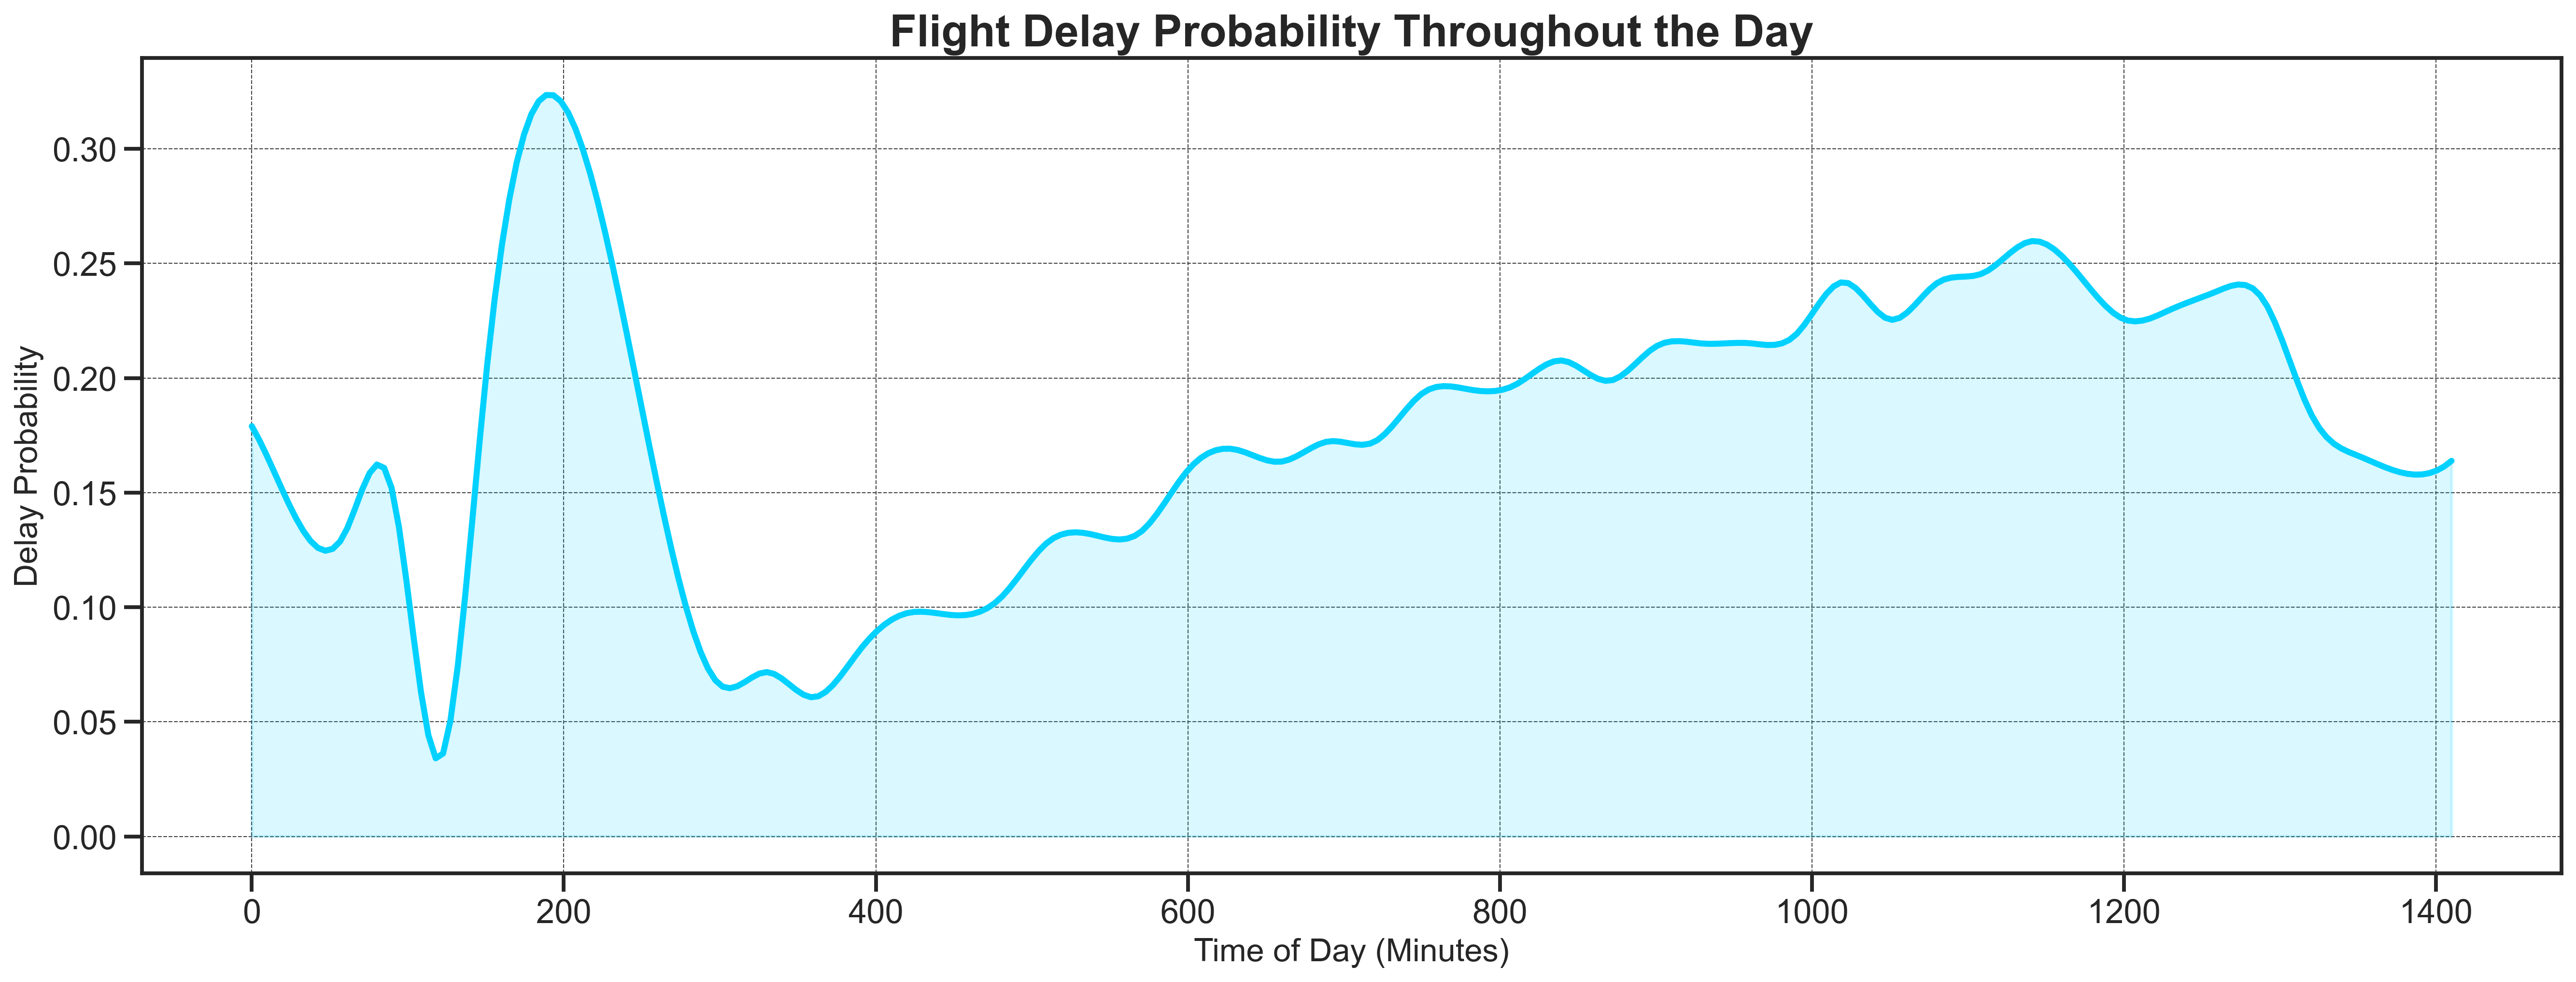

In [88]:
import numpy as np
from scipy.interpolate import make_interp_spline

plot_df = merged_df.copy()

plot_df["DepMinuteOfDay"] = plot_df["DepHour"] * 60 + plot_df["DepMinute"]
plot_df["Dep30Min"] = (plot_df["DepMinuteOfDay"] // 30) * 30

delay_30min = (
    plot_df.groupby("Dep30Min")["DEP_DEL15"]
    .mean()
    .reset_index()
)

x = delay_30min["Dep30Min"]
y = delay_30min["DEP_DEL15"]

# Smooth curve
x_smooth = np.linspace(x.min(), x.max(), 300)
y_smooth = make_interp_spline(x, y)(x_smooth)

plt.figure(figsize=(18, 7))

plt.plot(x_smooth, y_smooth, color=primary)
plt.fill_between(x_smooth, y_smooth, alpha=0.15, color=primary)

plt.title("Flight Delay Probability Throughout the Day", weight="bold")
plt.xlabel("Time of Day (Minutes)")
plt.ylabel("Delay Probability")

plt.grid(color=grid_color, linestyle="--", linewidth=0.5)

plt.tight_layout()

# SAVE AS HIGH-QUALITY IMAGE
plt.savefig("delay_vs_time.png", bbox_inches="tight")

plt.show()

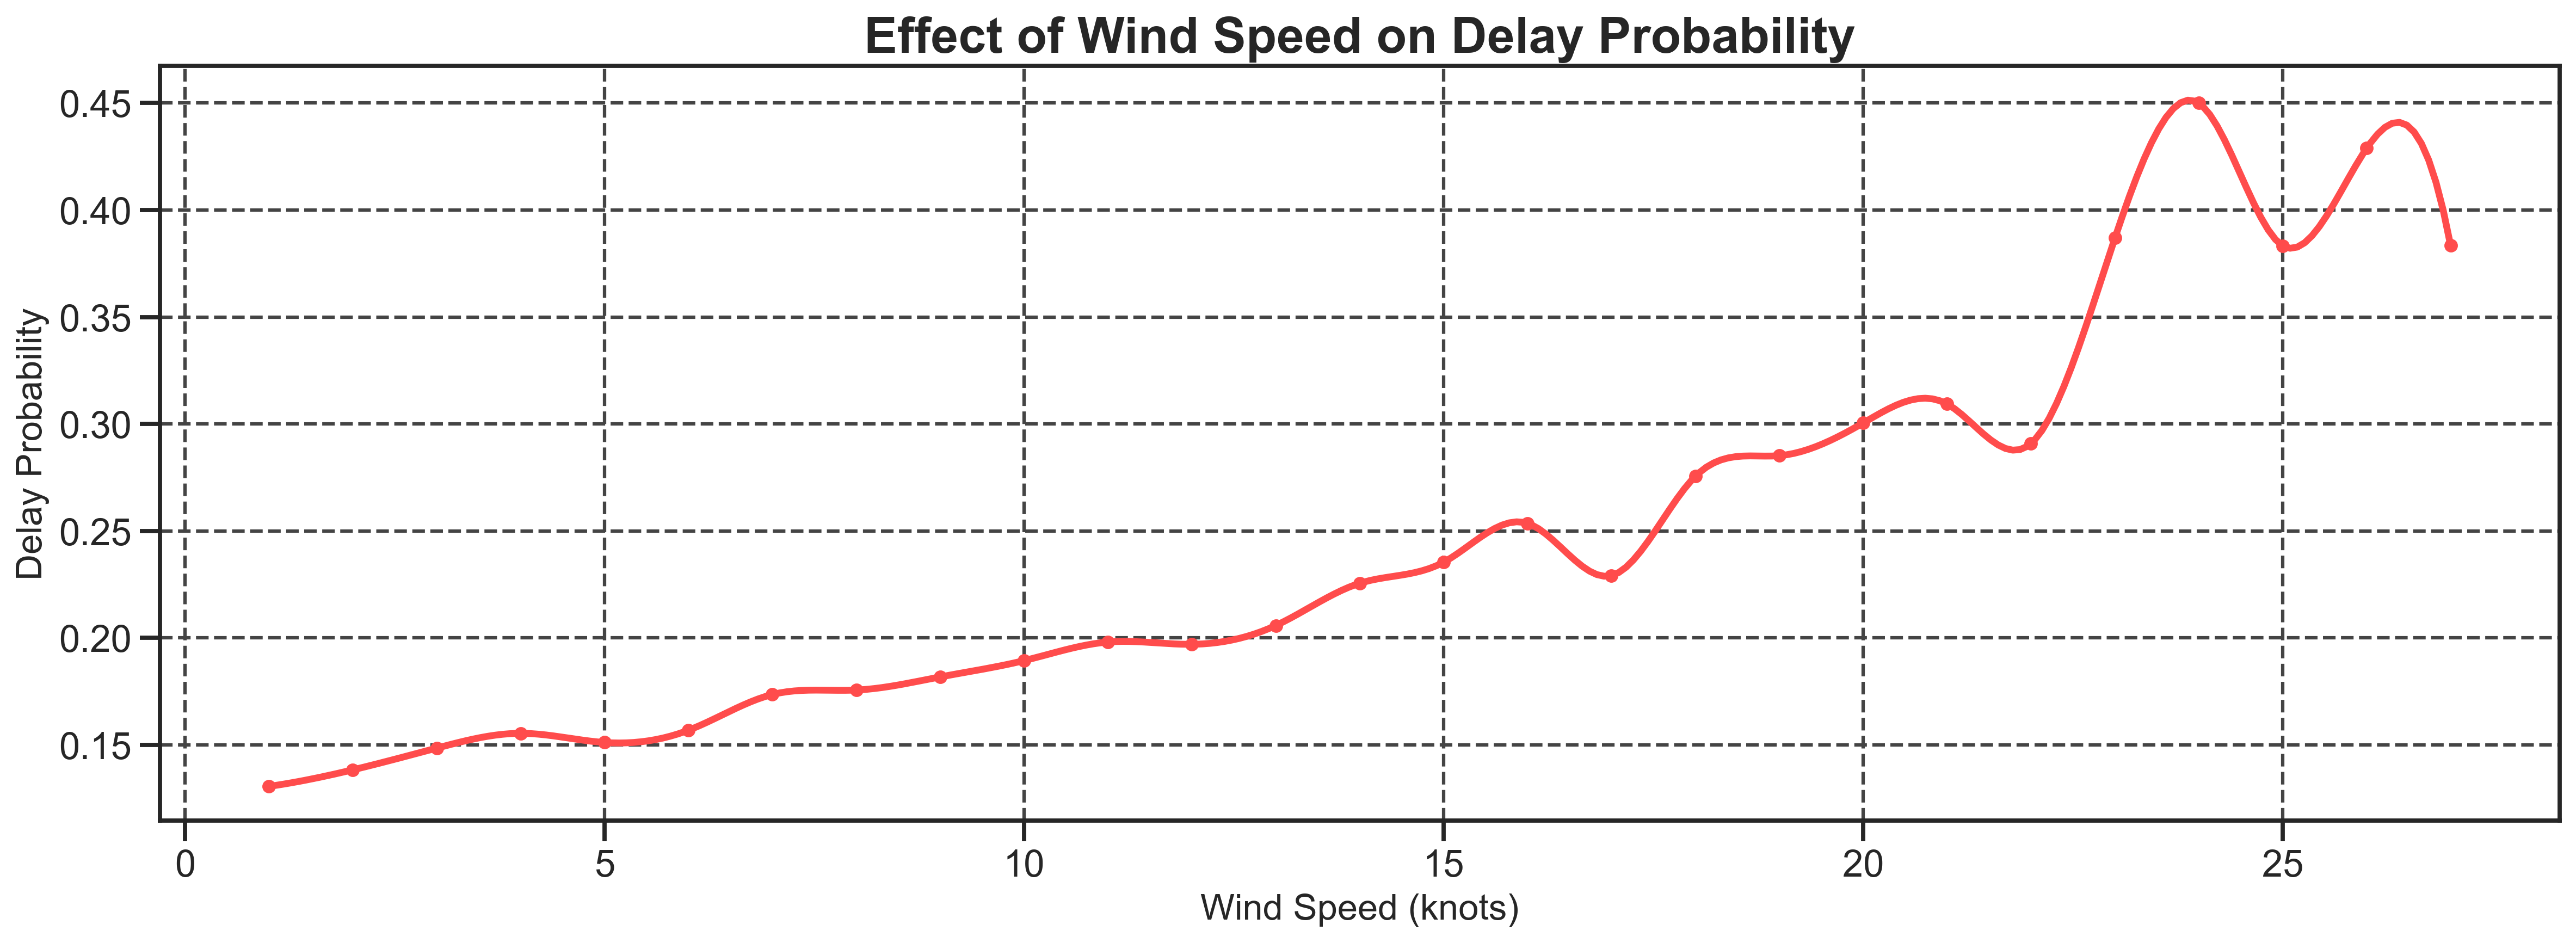

In [89]:
plot_df["wind_knots"] = plot_df["sknt"].round().astype("Int64")

wind_delay = (
    plot_df.groupby("wind_knots")["DEP_DEL15"]
    .agg(["mean", "count"])
    .reset_index()
)

wind_delay = wind_delay[wind_delay["count"] >= 200]

x = wind_delay["wind_knots"]
y = wind_delay["mean"]

x_smooth = np.linspace(x.min(), x.max(), 300)
y_smooth = make_interp_spline(x, y)(x_smooth)

plt.figure(figsize=(16, 6))

plt.plot(x_smooth, y_smooth, color=secondary)
plt.scatter(x, y, color=secondary, s=20)

plt.title("Effect of Wind Speed on Delay Probability", weight="bold")
plt.xlabel("Wind Speed (knots)")
plt.ylabel("Delay Probability")

plt.grid(color=grid_color, linestyle="--")

plt.tight_layout()
plt.savefig("wind_vs_delay.png", bbox_inches="tight")

plt.show()

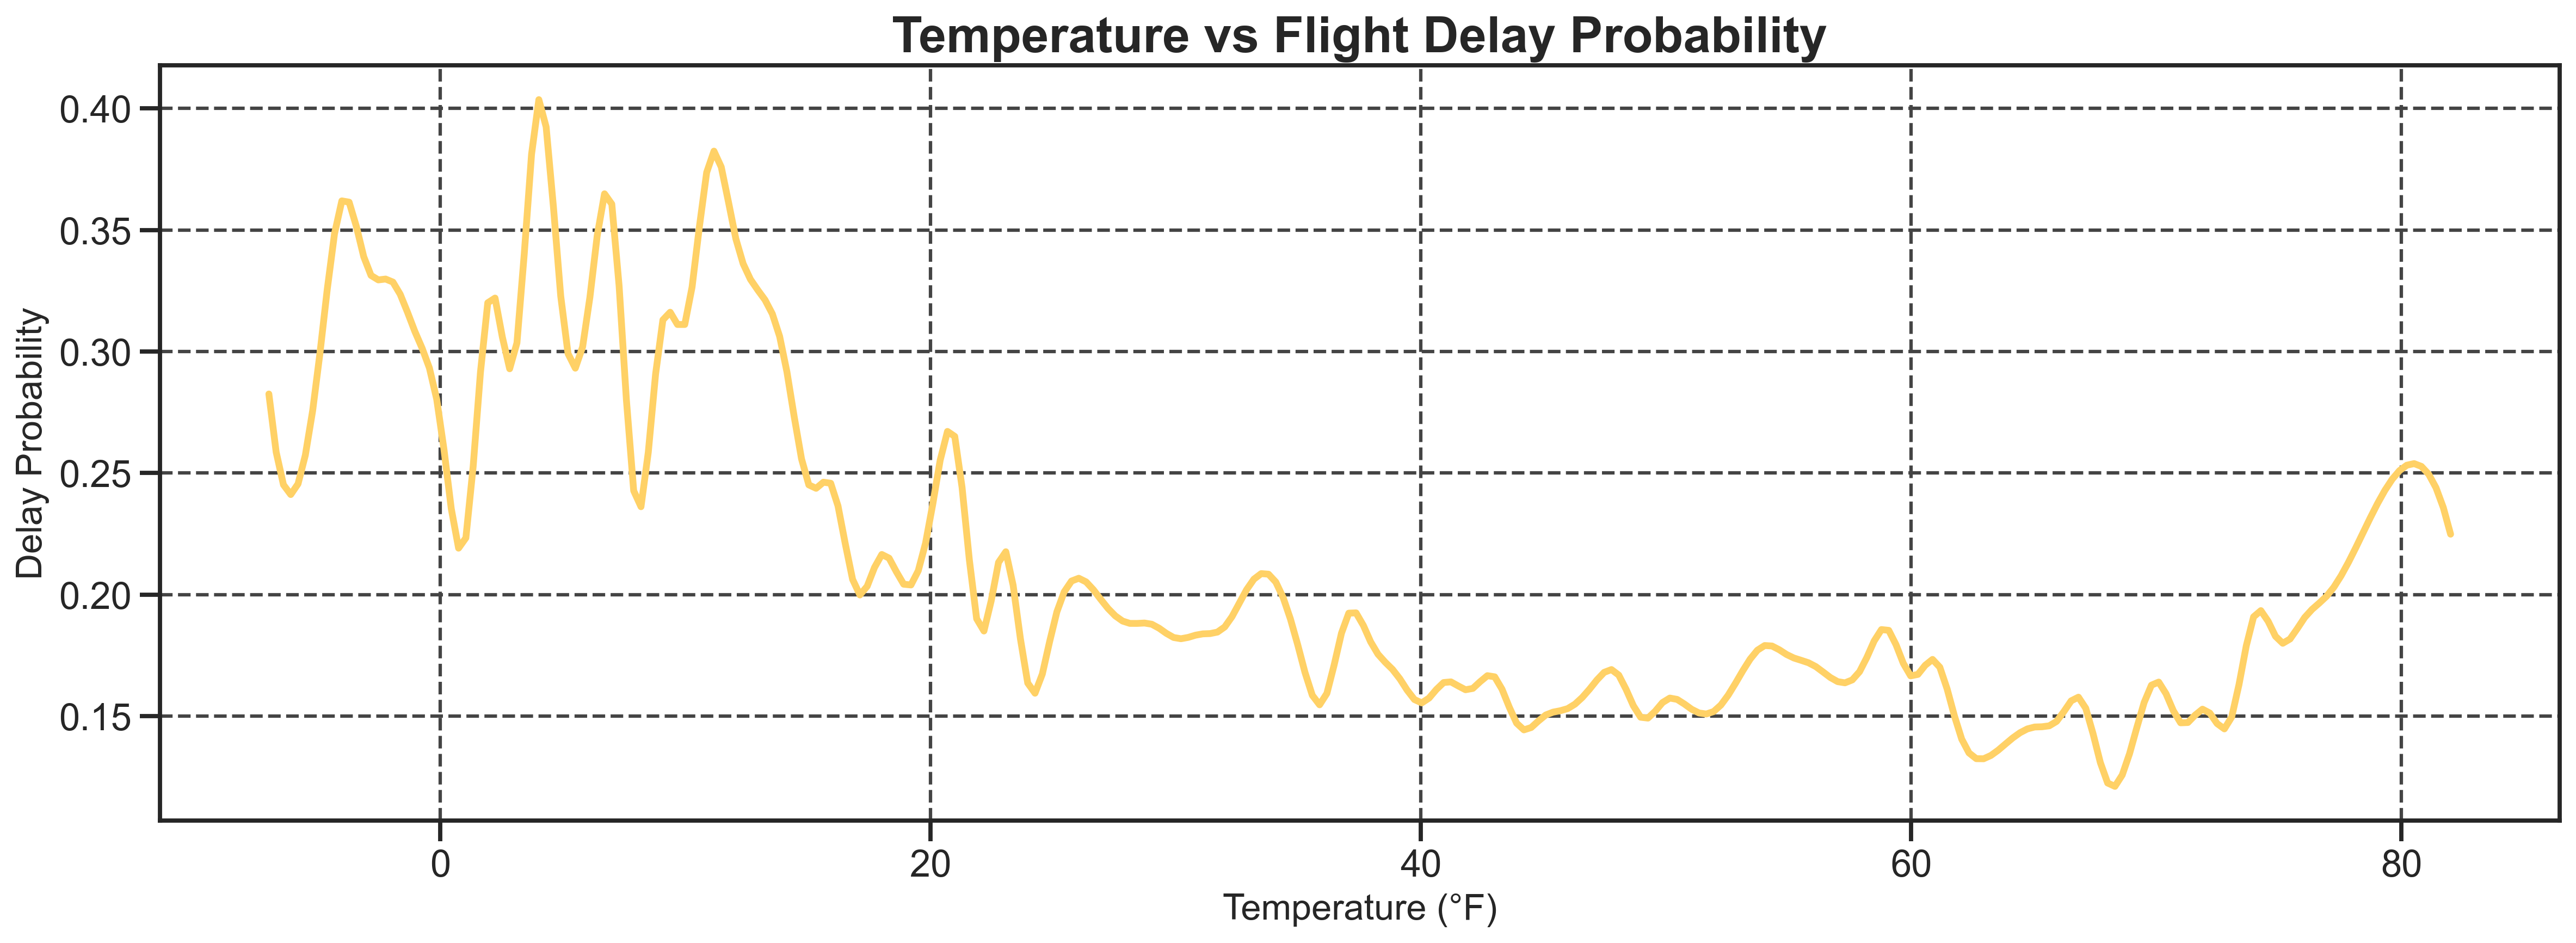

In [90]:
plot_df["temp_1f"] = plot_df["tmpf"].round()

temp_delay = (
    plot_df.groupby("temp_1f")["DEP_DEL15"]
    .agg(["mean", "count"])
    .reset_index()
)

temp_delay = temp_delay[temp_delay["count"] >= 200]

x = temp_delay["temp_1f"]
y = temp_delay["mean"]

x_smooth = np.linspace(x.min(), x.max(), 300)
y_smooth = make_interp_spline(x, y)(x_smooth)

plt.figure(figsize=(16, 6))

plt.plot(x_smooth, y_smooth, color=accent)

plt.title("Temperature vs Flight Delay Probability", weight="bold")
plt.xlabel("Temperature (°F)")
plt.ylabel("Delay Probability")

plt.grid(color=grid_color, linestyle="--")

plt.tight_layout()
plt.savefig("temp_vs_delay.png", bbox_inches="tight")

plt.show()

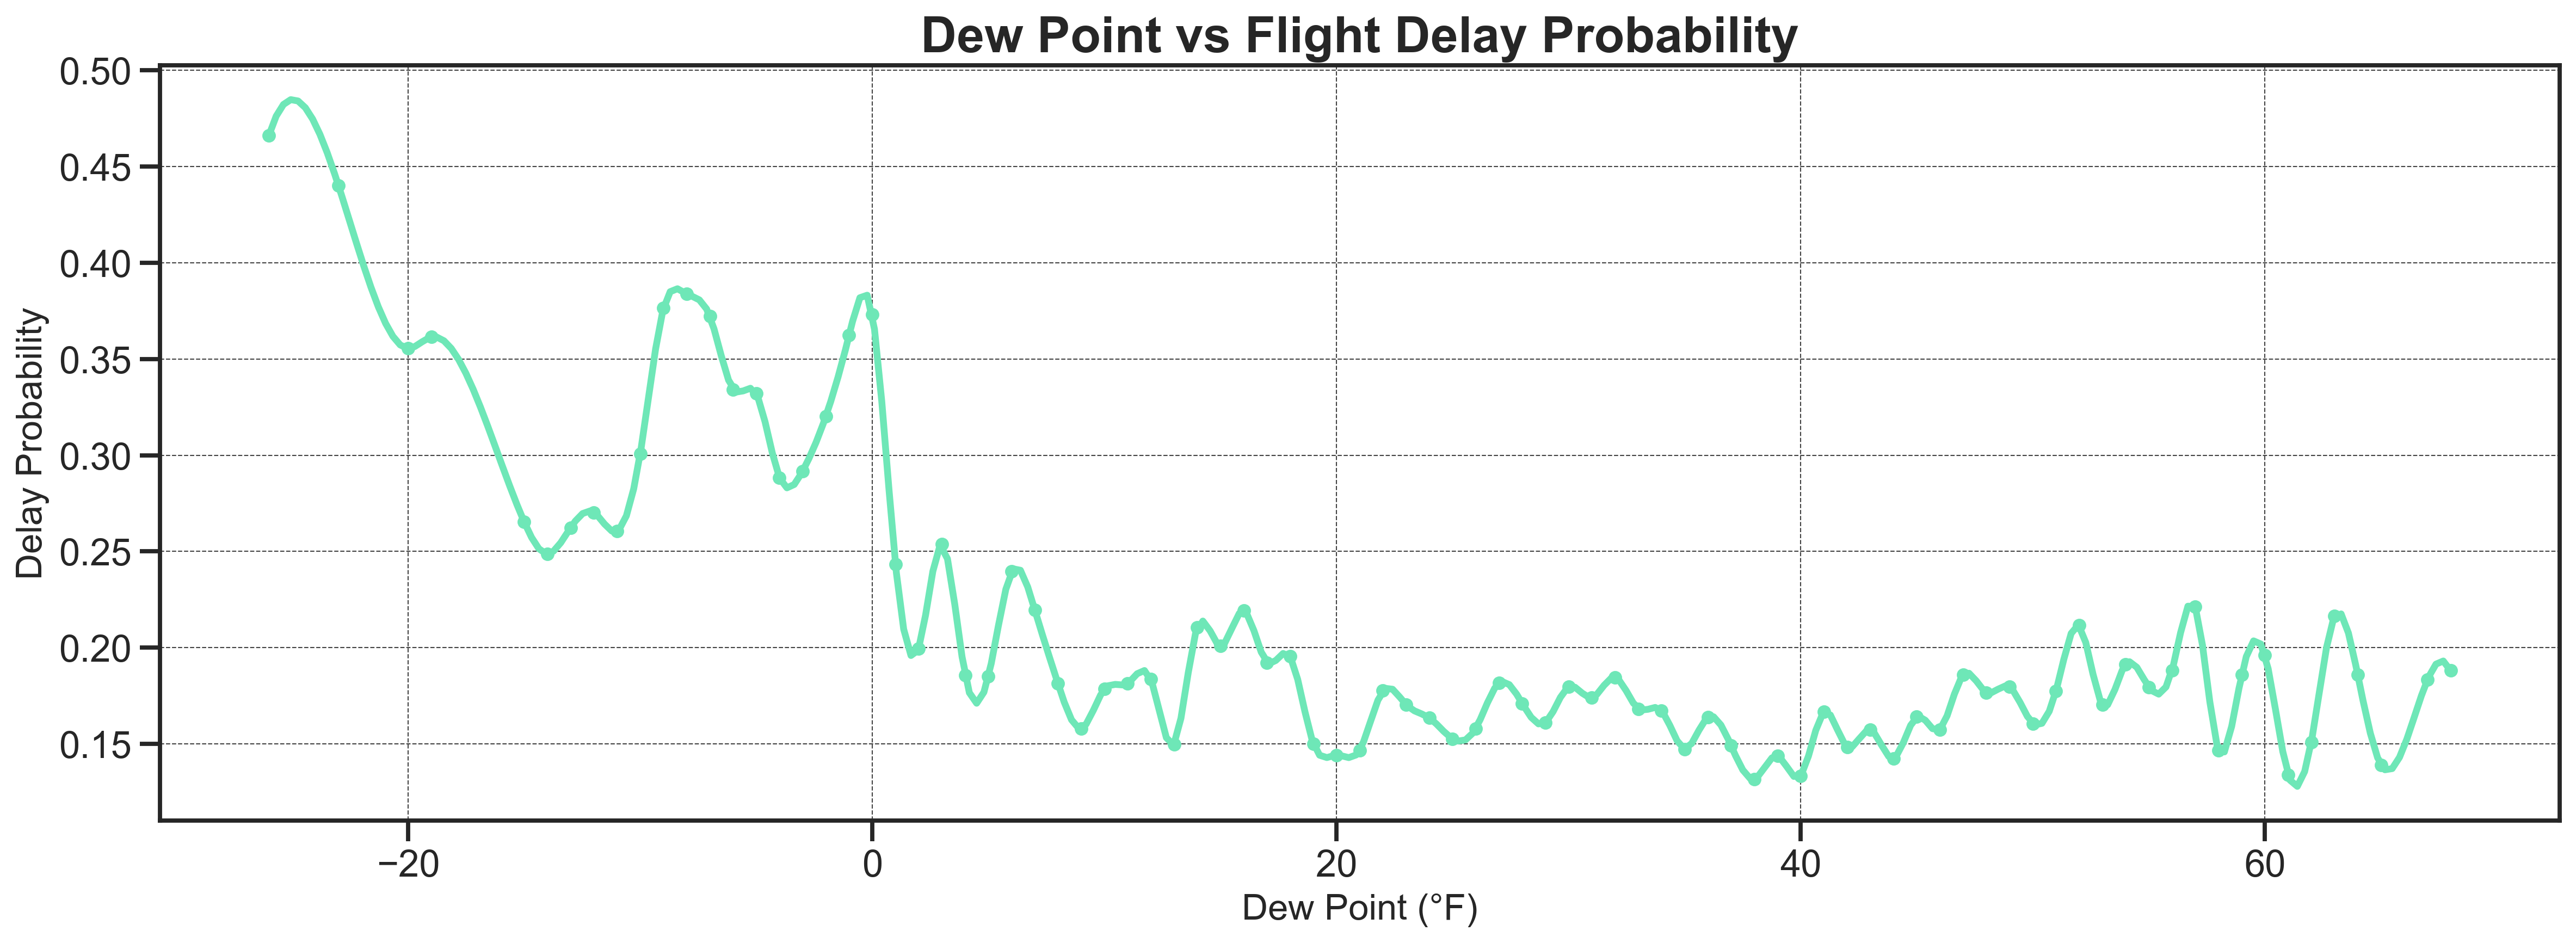

In [95]:
plot_df["dewpoint_1f"] = plot_df["dwpf"].round()

dew_delay = (
    plot_df.groupby("dewpoint_1f")["DEP_DEL15"]
    .agg(["mean", "count"])
    .reset_index()
)

dew_delay = dew_delay[dew_delay["count"] >= 200]

x = dew_delay["dewpoint_1f"]
y = dew_delay["mean"]

x_smooth = np.linspace(x.min(), x.max(), 300)
y_smooth = make_interp_spline(x, y)(x_smooth)

plt.figure(figsize=(16, 6))
plt.plot(x_smooth, y_smooth, color=green)
plt.scatter(x, y, color=green, s=20)

plt.title("Dew Point vs Flight Delay Probability", weight="bold")
plt.xlabel("Dew Point (°F)")
plt.ylabel("Delay Probability")
plt.grid(color=grid_color, linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.savefig("dewpoint_vs_delay.png", bbox_inches="tight")
plt.show()

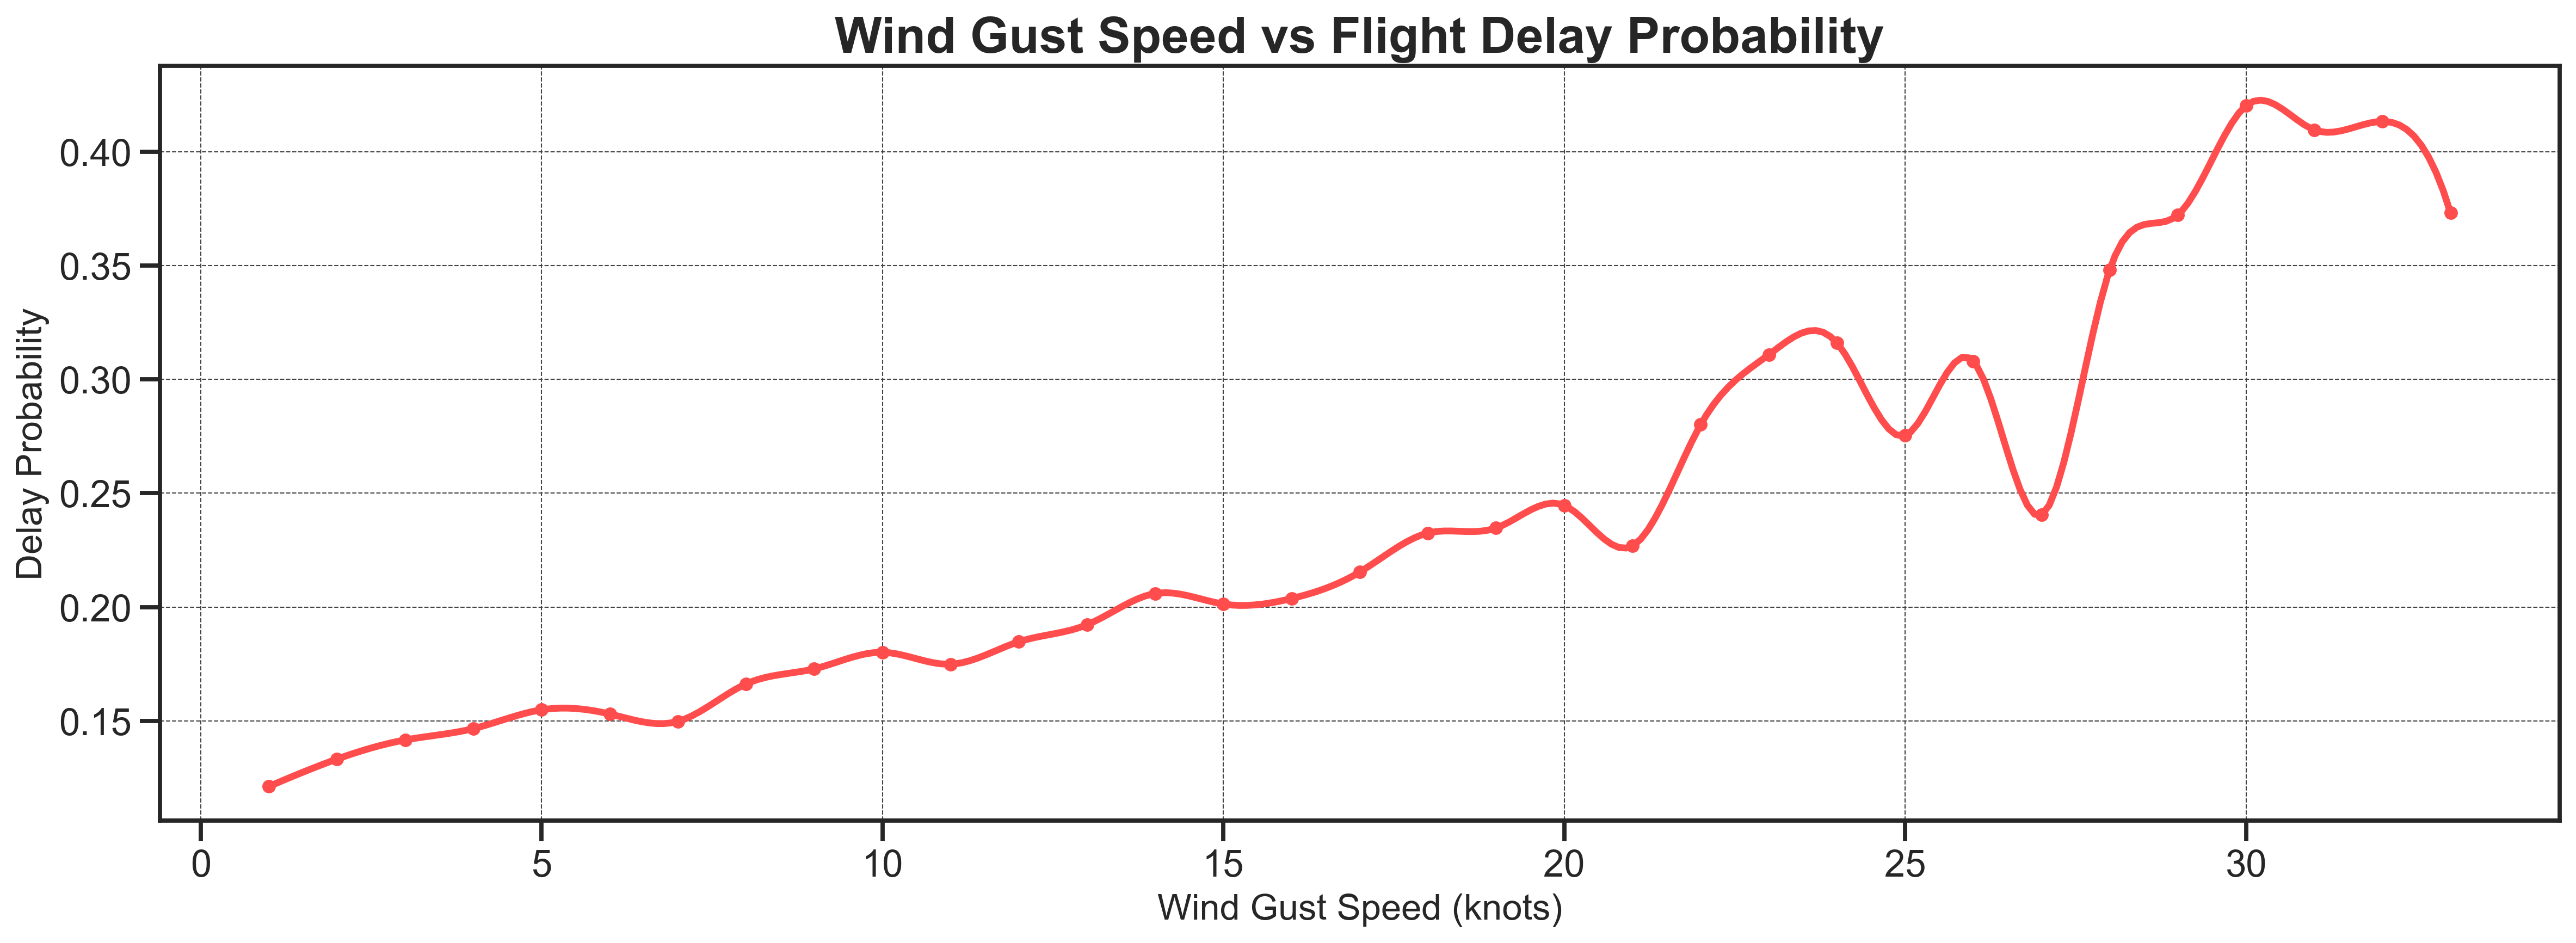

In [97]:
plot_df["gust_knots"] = plot_df["gust_sknt"].round().astype("Int64")

gust_delay = (
    plot_df.groupby("gust_knots")["DEP_DEL15"]
    .agg(["mean", "count"])
    .reset_index()
)

gust_delay = gust_delay[gust_delay["count"] >= 200]

x = gust_delay["gust_knots"].astype(float)
y = gust_delay["mean"]

x_smooth = np.linspace(x.min(), x.max(), 300)
y_smooth = make_interp_spline(x, y)(x_smooth)

plt.figure(figsize=(16, 6))
plt.plot(x_smooth, y_smooth, color=secondary)
plt.scatter(x, y, color=secondary, s=20)

plt.title("Wind Gust Speed vs Flight Delay Probability", weight="bold")
plt.xlabel("Wind Gust Speed (knots)")
plt.ylabel("Delay Probability")
plt.grid(color=grid_color, linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.savefig("gust_vs_delay.png", bbox_inches="tight")
plt.show()

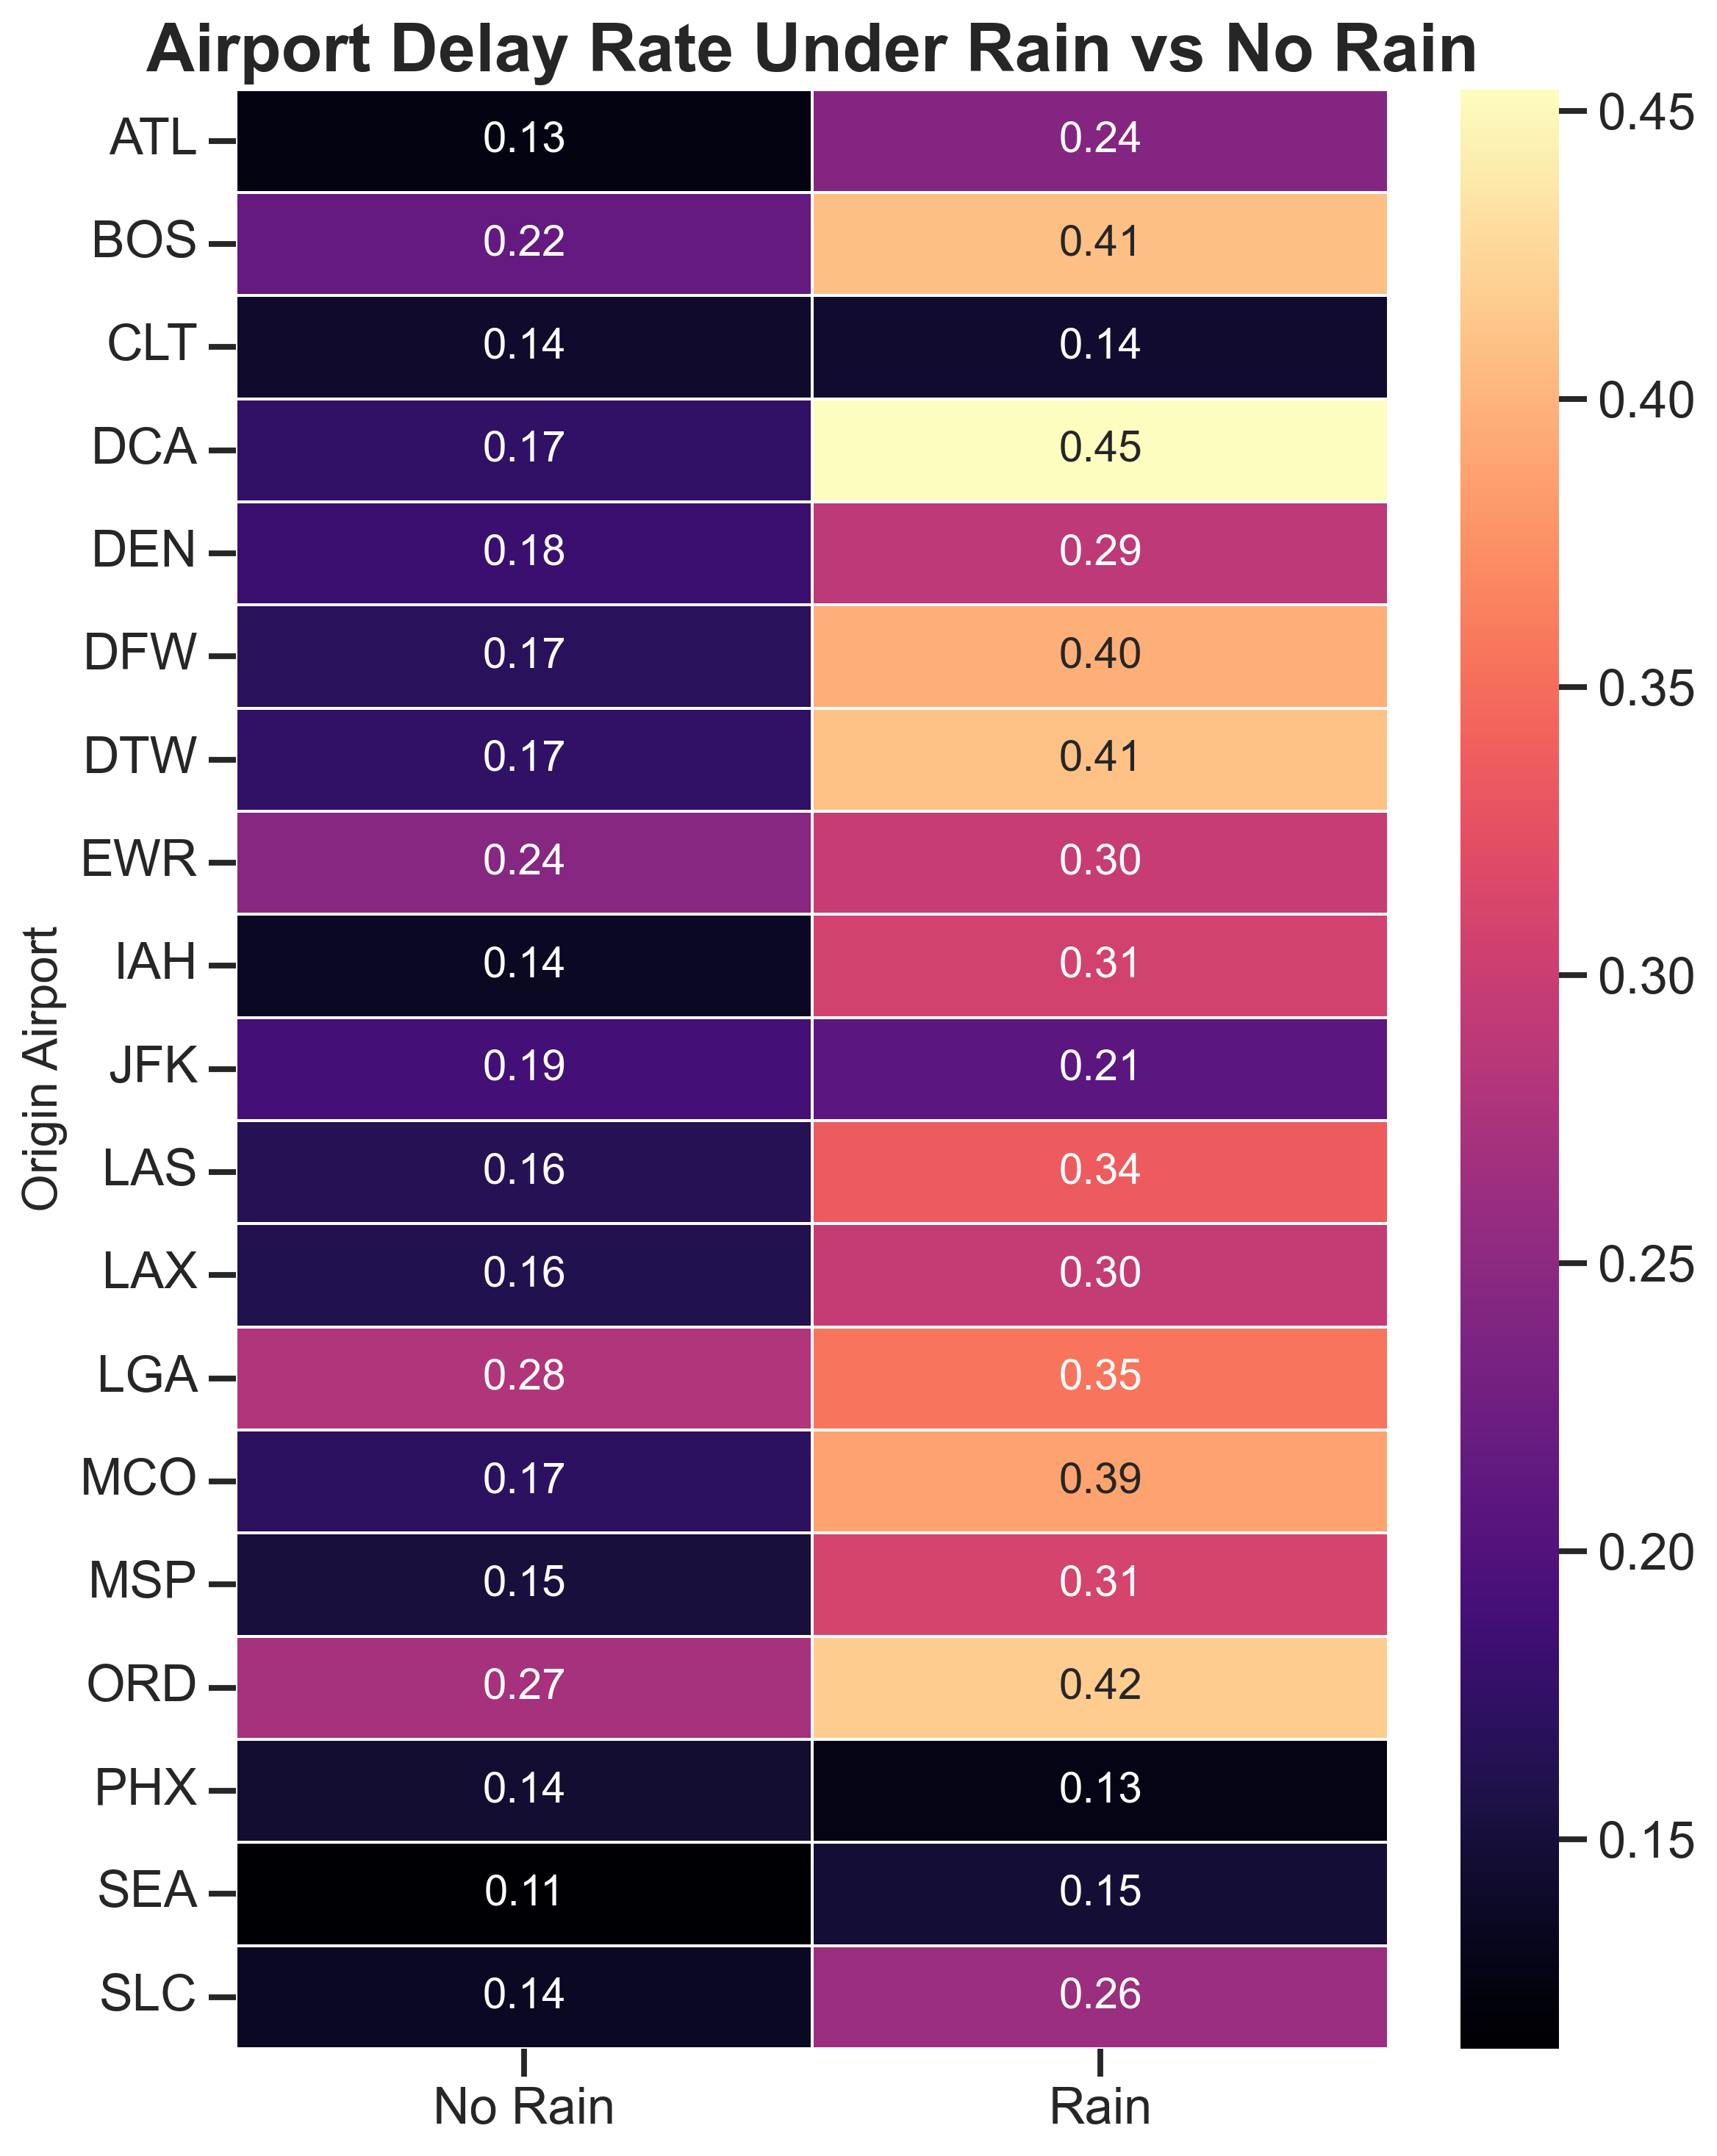

In [98]:
airport_weather = plot_df.copy()

airport_weather["Rain"] = np.where(airport_weather["precip"] > 0, "Rain", "No Rain")

heatmap_data = (
    airport_weather
    .groupby(["ORIGIN", "Rain"])["DEP_DEL15"]
    .mean()
    .reset_index()
    .pivot(index="ORIGIN", columns="Rain", values="DEP_DEL15")
)

plt.figure(figsize=(8, 10))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="magma",
    linewidths=0.5
)

plt.title("Airport Delay Rate Under Rain vs No Rain", weight="bold")
plt.xlabel("")
plt.ylabel("Origin Airport")
plt.tight_layout()
plt.savefig("airport_rain_heatmap.png", bbox_inches="tight")
plt.show()